# Environnement

In [1]:
from config import Config, PROCESS_TYPE, MODEL_TYPE, DatasetPaths

config = Config(PROCESS=[PROCESS_TYPE.data_splitting_test_val,PROCESS_TYPE.normalize_img,PROCESS_TYPE.img_cropping],PROCESSED=[], MESSAGE="try to limit overfitting with smallest image size and only splitting test and val set", IMG_SIZE=(64, 64), MODEL=MODEL_TYPE.logistic_regression)
dataset_paths = DatasetPaths.load()


# Dataset


## Splitting by label

In [2]:
from splitting import data_splitting_val, data_splitting_all
from utils import display_distribution, dataset_checker, crop_images
from PIL import Image
import matplotlib.pyplot as plt

if PROCESS_TYPE.data_splitting_label in config.PROCESS :
    dataset_paths.train_pneumonia_paths = dataset_paths.train_pneumonia_paths[:len(dataset_paths.train_normal_paths)]
    dataset_paths.val_pneumonia_paths = dataset_paths.val_pneumonia_paths[:len(dataset_paths.val_normal_paths)]

## Splitting by category

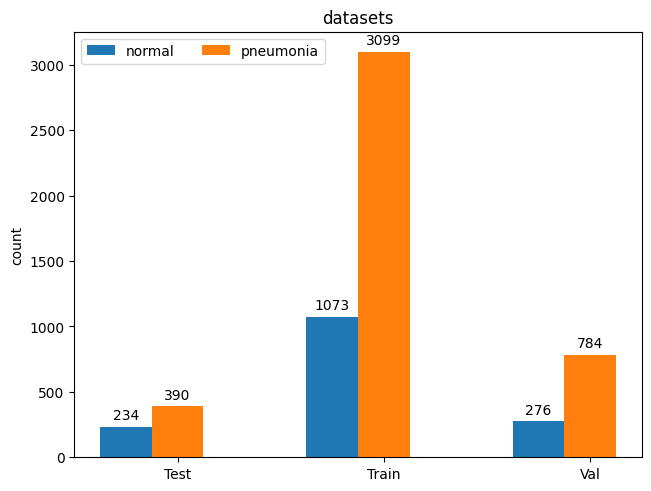

In [3]:
if PROCESS_TYPE.data_spliting_category in config.PROCESS :
    train_paths, val_paths, test_paths, y_train, y_val, y_test = data_splitting_all(config, dataset_paths.train_normal_paths, dataset_paths.train_pneumonia_paths, dataset_paths.val_normal_paths, dataset_paths.val_pneumonia_paths, dataset_paths.test_normal_paths, dataset_paths.test_pneumonia_paths)
elif PROCESS_TYPE.data_splitting_test_val in config.PROCESS :
    train_paths, val_paths, y_train, y_val = data_splitting_val(config, dataset_paths.train_normal_paths, dataset_paths.train_pneumonia_paths, dataset_paths.val_normal_paths, dataset_paths.val_pneumonia_paths)
    test_paths = dataset_paths.test_normal_paths + dataset_paths.test_pneumonia_paths
    y_test = [0] * len(dataset_paths.test_normal_paths) + [1] * len(dataset_paths.test_pneumonia_paths)

display_distribution([test_path for test_path in test_paths if test_path.parent.name == "NORMAL"], [test_path for test_path in test_paths if test_path.parent.name == "PNEUMONIA"], [train_path for train_path in train_paths if train_path.parent.name == "NORMAL"], [train_path for train_path in train_paths if train_path.parent.name == "PNEUMONIA"], [val_path for val_path in val_paths if val_path.parent.name == "NORMAL"], [val_path for val_path in val_paths if val_path.parent.name == "PNEUMONIA"])

## Cropping

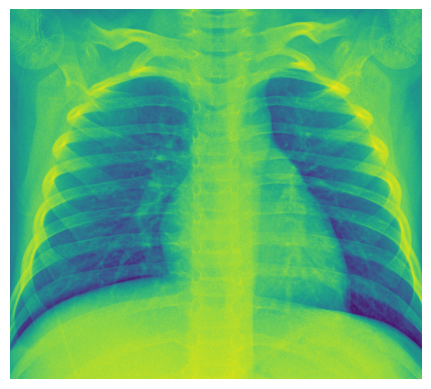

In [ ]:


if PROCESS_TYPE.img_cropping in config.PROCESS: 
        config.PROCESSED.append(PROCESS_TYPE.img_cropping)
        train_paths, val_paths, test_paths = crop_images(train_paths, "train"), crop_images(val_paths, "val"), crop_images(test_paths, "test")
        img = Image.open(train_paths[0])

        plt.imshow(img)
        plt.axis("off")
        plt.show()

## Checker

In [5]:

dataset_checker(train_paths, y_train)
dataset_checker(val_paths, y_val)
dataset_checker(test_paths, y_test)

## Normalize

In [6]:
from normalize import normalize_img, normalise_pixel

assert PROCESS_TYPE.normalize_img in config.PROCESS
X_train, X_val, X_test = normalize_img(config, train_paths, val_paths, test_paths)

if PROCESS_TYPE.normalize_pixel in config.PROCESS:
    X_train, X_val, X_test = normalise_pixel(config, X_train, X_val, X_test)

ModuleNotFoundError: No module named 'normalize'

# Compute 

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


param_grid = [
    {
        "solver": ["lbfgs"],
        "max_iter": [2000],
        "l1_ratio": [0], 
        "C": [0.01, 0.1, 1, 10],
        "class_weight": [None, "balanced"]
    },
    {
        "solver": ["liblinear"],
        "max_iter": [2000],
        "l1_ratio": [0, 1],  
        "C": [0.01, 0.1, 1, 10],
        "class_weight": [None, "balanced"]
    },
    {
        "solver": ["saga"],
        "max_iter": [6000],
        "l1_ratio": [0, 0.5, 1],  
        "C": [0.01, 0.1, 1],
        "class_weight": [None, "balanced"]
    }
]


if PROCESS_TYPE.grid_search in config.PROCESS:
    if config.MODEL == MODEL_TYPE.logistic_regression:
        print("Performing grid search...")
        grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=3, n_jobs=-1, verbose=3)
        grid_search.fit(X_train+X_val, y_train+y_val)
        print("Best parameters: ", grid_search.best_params_)
        model = grid_search.best_estimator_
    else : 
        raise ValueError("Grid search is only implemented for logistic regression")

else:
    model = LogisticRegression(max_iter=config.MAX_ITER) if config.MODEL == MODEL_TYPE.logistic_regression else None
    if model is None:
        raise ValueError("Model not implemented")

    model.fit(X_train, y_train)

y_pred = model.predict(X_test)


# Result Visualization

# Register

In [ ]:
import pandas as pd
from result import evaluate_model

evaluate_model(config, model, X_train, y_train, X_test, y_test, y_pred)

## Compare

### Details :

- **accuracy**: proportion of correct predictions made by the model.

- **cv_auc**: AUC computed using 5-fold cross-validation on the training set.  
  It helps estimate how well the model separates the two classes.  
  The standard deviation indicates how stable the model is across different splits of the data.

- **recall**: measures the ability of the model to correctly detect pneumonia cases.  
  In this context, recall is important because false negatives (predicting normal when the patient has pneumonia) are dangerous.  
  Therefore, it is better to have more false positives than false negatives.

- **precision**: measures how many predicted pneumonia cases are actually correct.  
  It is useful to compare with recall because a model with very high recall may produce many false positives.

- **f1_score**: harmonic mean of precision and recall.  
  It balances the two metrics and penalizes models that perform poorly on one of them.

- **test_auc**: measures the ability of the model to distinguish between classes independently of the classification threshold. if cv_aux is highter and test_auc is lower, we have a case of overfitting. 

- **processed**: list all process used on the dataset

In [ ]:
from typing import Any, Dict
import json
from datetime import datetime

results: Dict[str, Any]  = {}

with open("version.json", "r") as f:
    version_data = json.load(f)["versions"]
    for date, data in version_data.items():
        key_date = datetime.fromisoformat(date)
        results[key_date] = {
            "accuracy": f"{data['results']['accuracy']:.3f}",
            "cv_auc": f"{data['results']['cv_auc'][0]:.3f} ± {data['results']['cv_auc'][1]:.3f}",
            "recall": f"{data['results']['recall']:.3f}",
            "precision": f"{data.get('results', {}).get('precision', 0):.3f}",
            "f1_score": f"{data.get('results', {}).get('f1_score', 0):.3f}",
            "test_auc": f"{data['results']['test_auc']:.3f}",
            "processed": f"‘{', '.join(data['envs']['PROCESS'])}’",
        }

df = pd.DataFrame.from_dict(results, orient="index")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
print(df)

- [] tester avec une meilleur répartition malade _ non malade 
- [] a quoi sert le val dataset 
- [] faire 2 ou 3 notebook par partie du projet pour éviter de devoir tout relancer à chaque fois
- [] tester d'autre modèle 


Question : 
- pas de data augmentation car j'ai pas de sous-apprentissage
- class weight car bcp de donnée en normal
- si on fait une regression logistique avec les trois classe, doit-on faire un model pour normal/pneumonia puis un autre pour virus/bacterie


=> PCA pour réduire la dimension car over fitting meme après grid search 
=> commentaire entre chaque expérience sur résultat hypothèse pour résoudre le prob
=> grid search => il faut y ajouter le test et la val car c'est lui qui gère direct la séparation val et train 